# **GROUP 2 - NATURAL LANGUAGE PROCESSING**


---


## **"Implementation of Guardrails for Moderating Code-Mixed Hate Speech on Indonesian Social Media"**


---



### **Names of Group Members :**
### 1) Michael Respati Sanjaya Ho - 535250008
### 2) Felix Lin - 535250044
### 3) Charlie Jhodya Soe - 535250180


---



## **Tarumanagara University**





**PREPARING LIBRARIES AND THE GPU**

- Installing the libraries required for:
- data pre-processing
- retrieving the dataset
- fine-tuning the Transformer model
- model evaluation
- training using the GPU



In [1]:
# Installation
!pip install transformers datasets scikit-learn pandas accelerate -q

# Data and Utilities
import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import train_test_split

# Configuration
RANDOM_STATE = 42
TEST_SIZE = 0.2
VAL_SIZE = 0.1

print("GPU Ready:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

GPU Ready: True
GPU: Tesla T4


**DOWNLOAD THE IBROHIM & BUDI DATASET**

Download:
1. The hate speech dataset from Ibrohim & Budi
2. The slang normalisation dictionary (alay dictionary)

The main dataset is used as one of the data sources
for training hate speech detection models.


In [2]:
import requests

url1 = "https://raw.githubusercontent.com/okkyibrohim/id-multi-label-hate-speech-and-abusive-language-detection/master/re_dataset.csv"
url2 = "https://raw.githubusercontent.com/okkyibrohim/id-multi-label-hate-speech-and-abusive-language-detection/master/new_kamusalay.csv"

open("re_dataset.csv", "wb").write(requests.get(url1).content)
open("new_kamusalay.csv", "wb").write(requests.get(url2).content)

285941

**LOADING AND INITIAL CHECK OF THE DATASET**

Reading the Ibrohim & Budi dataset and the ‘alay’ slang dictionary.

Checks carried out:
 - number of data points
 - distribution of hate speech labels
 - missing values
 - duplicate Tweets
 - percentage of labels
 - sample dataset content

Following the checks, duplicate Tweets were removed.


In [3]:
df = pd.read_csv('re_dataset.csv', encoding='latin-1')
alay_dictionary = pd.read_csv('new_kamusalay.csv', encoding='latin-1', header=None, names=['alay', 'baku'])

print("Amount of Data:", df.shape)
print("Distribution of HS codes (1=hate speech, 0=not):")
print(df['HS'].value_counts())
df[['Tweet', 'HS', 'Abusive']].head()

# Check for missing values
print("Missing value:")
print(df[['Tweet', 'HS']].isnull().sum())

# Check for duplicates
print("\nNumber of duplicate Tweets:")
print(df['Tweet'].duplicated().sum())

# Check the label distribution
print("\nHS Distribution:")
print(df['HS'].value_counts())

# Label percentage
print("\nLabel percentage:")
print(df['HS'].value_counts(normalize=True) * 100)

# Data Example
display(df[['Tweet', 'HS', 'Abusive']].head(10))

# Delete duplicate tweets
before = len(df)

df = df.drop_duplicates(subset='Tweet').reset_index(drop=True)

after = len(df)

print("Data before removing duplicates:", before)
print("Data after removing duplicates:", after)
print("Duplicates removed:", before - after)

Amount of Data: (13169, 13)
Distribution of HS codes (1=hate speech, 0=not):
HS
0    7608
1    5561
Name: count, dtype: int64
Missing value:
Tweet    0
HS       0
dtype: int64

Number of duplicate Tweets:
146

HS Distribution:
HS
0    7608
1    5561
Name: count, dtype: int64

Label percentage:
HS
0    57.77204
1    42.22796
Name: proportion, dtype: float64


,Tweet,HS,Abusive
0,- disaat semua cowok berusaha melacak perhatia...,1,1
1,RT USER: USER siapa yang telat ngasih tau elu?...,0,1
2,"41. Kadang aku berfikir, kenapa aku tetap perc...",0,0
3,USER USER AKU ITU AKU\n\nKU TAU MATAMU SIPIT T...,0,0
4,USER USER Kaum cebong kapir udah keliatan dong...,1,1
5,USER Ya bani taplak dkk \xf0\x9f\x98\x84\xf0\x...,1,1
6,deklarasi pilkada 2018 aman dan anti hoax warg...,0,0
7,Gue baru aja kelar re-watch Aldnoah Zero!!! pa...,0,1
8,Nah admin belanja satu lagi port terbaik nak m...,0,0
9,USER Enak lg klo smbil ngewe',0,1


Data before removing duplicates: 13169
Data after removing duplicates: 13023
Duplicates removed: 146


**LOAD CODE-MIXED DATASET**

 Retrieving a hate speech dataset comprising:
 - Indonesian + Javanese
 - Indonesian + Sundanese

In [4]:
from datasets import load_dataset

ds_jv = load_dataset('aiatums/codemixed-id-hate-speech', 'Indonesian-Javanese')
ds_su = load_dataset('aiatums/codemixed-id-hate-speech', 'Indonesian-Sundanese')

print(ds_jv)
print(ds_jv['train'][0])

DatasetDict({
    train: Dataset({
        features: ['original', 'augmented_1', 'augmented_2', 'augmented_3', 'augmented_4', 'augmented_5', 'label', 'llm', 'strategy', 'language_pair', 'split'],
        num_rows: 45144
    })
    test: Dataset({
        features: ['original', 'augmented_1', 'augmented_2', 'augmented_3', 'augmented_4', 'augmented_5', 'label', 'llm', 'strategy', 'language_pair', 'split'],
        num_rows: 1000
    })
})
{'original': 'USER USER USER USER Yah keluar konteks dasar pekok', 'augmented_1': 'USER USER USER USER Yah iki metu konteks, dasar pekok.', 'augmented_2': 'USER USER USER USER Lah ngomongmu keluar konteks, dasare pekok.', 'augmented_3': 'USER USER USER USER Heh ra nyambung blas, keluar konteks, dasar pekok.', 'augmented_4': 'USER USER USER USER Ya kok malah metu konteks, pekok tenan.', 'augmented_5': 'USER USER USER USER Woy omonganmu metu konteks terus wae, dasar pekok.', 'label': 'hate speech', 'llm': 'GPT-5', 'strategy': 'Paraphrasing', 'language_pai

**COMBINE DATASETS**

 Convert the Javanese and Sundanese datasets into pandas DataFrames, standardise the column names "Tweet" and "HS", then convert the text labels into numbers:

 1 = hate speech

 0 = not hate speech

The code-mixed dataset is then combined with the Ibrohim & Budi dataset.


In [5]:
df_jv = ds_jv['train'].to_pandas()
df_su = ds_su['train'].to_pandas()

def create_codemixed_line(df_source):
    rows = []
    for idx, row in df_source.iterrows():
        group_id = f"src_{idx}"  # note: these lines are taken from the same source sentence
        label = 1 if row['label'] == 'hate speech' else 0
        # Use the original + 2 augmented samples (not all 5, so that the training time doesn’t triple)
        for column in ['original', 'augmented_1', 'augmented_2']:
            rows.append({'Tweet': row[column], 'HS': label, 'group_id': group_id})
    return pd.DataFrame(rows)

df_codemixed = pd.concat([create_codemixed_line(df_jv), create_codemixed_line(df_su)], ignore_index=True)

print("Number of failed labels (should be 0):", df_codemixed['HS'].isnull().sum())
print("Total number of code-mixed lines (original + 2 augmented):", len(df_codemixed))

# Also include the group_id in the data for Ibrohim and Budi (each row represents its own group; there are no variations)
df['group_id'] = ['ib_' + str(i) for i in range(len(df))]

before = len(df)
df = pd.concat([df, df_codemixed], ignore_index=True)
print(f"Before: {before} | After: {len(df)}")

Number of failed labels (should be 0): 0
Total number of code-mixed lines (original + 2 augmented): 270864
Before: 13023 | After: 283887


**CHECK FOR DATA DUPLICATES AFTER MERGING**

Checks:
 - duplicate Tweets across the entire dataset
 - text overlap between the Javanese and Sundanese datasets
 - number of rows after merging


In [6]:
# 1. Check for duplicates in the ENTIRE combined dataframe (not just the initial 13,000)
print("Duplicate tweets in the combined dataframe:", df['Tweet'].duplicated().sum())

# 2. Check the main hypothesis: are there many similarities between the "original" Javanese and Sundanese texts?
overlap = set(df_jv['original']) & set(df_su['original'])
print("The same 'original' text in both the Javanese and Sundanese configurations:", len(overlap))
print("From total:", len(df_jv), "(Javanese) and", len(df_su), "(Sundanese)")
# Check: is the current df really the result of just a single merge process, or are there any remaining duplicate processes?
print("Total rows df:", len(df))
print("It should be (13023 + 45144 + 45144):", 13023 + 45144 + 45144)

# Ensuring the dataset is not subject to duplicate merging
# If the figures match or are close, it means the duplicates are actually within the dataset itself

# See what the duplicate example looks like
print(df[df['Tweet'].duplicated(keep=False)].sort_values('Tweet')[['Tweet','HS']].head(10))

Duplicate tweets in the combined dataframe: 83178
The same 'original' text in both the Javanese and Sundanese configurations: 2
From total: 45144 (Javanese) and 45144 (Sundanese)
Total rows df: 283887
It should be (13023 + 45144 + 45144): 103311
       Tweet  HS
54938          1
42127          1
112580         0
50947          1
50948          1
20479          1
20480          1
51007          1
51008          1
51238          1


**HANDLING CONTRADICTORY AND DUPLICATE LABELS**

Searching for Tweets that have more than one different label.

If a Tweet contains conflicting labels, all instances of that Tweet are removed to ensure the dataset’s labels are consistent.
The dataset is then deduplicated again.

In [7]:
# View all rows containing that specific tweet, including the original strategy and language_pair columns
cek = df_codemixed[df_codemixed['Tweet'].str.contains('NewProfilePic no more ihan jurig', na=False, regex=False)]
print(cek)
# 1. Search for Tweets with different labels
label_per_tweet = df.groupby('Tweet')['HS'].nunique()
tweet_contradiction = label_per_tweet[label_per_tweet > 1].index
print("Number of tweets tagged with contradiction:", len(tweet_contradiction))

# 2. Delete Tweets with contradictory labels
before = len(df)
df = df[~df['Tweet'].isin(tweet_contradiction)].reset_index(drop=True)
print(f"Before resolving the contradiction: {before} | After: {len(df)}")

# 3. Remove duplicates
before = len(df)
df = df.drop_duplicates(subset='Tweet').reset_index(drop=True)
print(f"Before dedup: {before} | After: {len(df)}")

print(df['HS'].value_counts())

                                                    Tweet  HS   group_id
143409  #NewProfilePic no more ihan jurig (kalo kata c...   0   src_2659
154695  #NewProfilePic no more ihan jurig (kalo kata c...   0   src_6421
165981  #NewProfilePic no more ihan jurig (kalo kata c...   0  src_10183
177267  #NewProfilePic no more ihan jurig (kalo kata c...   0  src_13945
188553  #NewProfilePic no more ihan jurig (kalo kata c...   0  src_17707
199839  #NewProfilePic no more ihan jurig (kalo kata c...   0  src_21469
211122  #NewProfilePic no more ihan jurig (kalo kata c...   1  src_25230
222411  #NewProfilePic no more ihan jurig (kalo kata c...   0  src_28993
233697  #NewProfilePic no more ihan jurig (kalo kata c...   0  src_32755
244983  #NewProfilePic no more ihan jurig (kalo kata c...   0  src_36517
256269  #NewProfilePic no more ihan jurig (kalo kata c...   0  src_40279
267555  #NewProfilePic no more ihan jurig (kalo kata c...   0  src_44041
Number of tweets tagged with contradiction: 955
Bef

**TEXT PREPROCESSING**

Perform simple preprocessing:
1. Case folding → convert text to lower case
2. Remove user placeholders and URLs
3. Simple tokenisation based on spaces
4. Normalisation of slang using the ‘alay’ dictionary

The preprocessing results are stored in the `text_clean` column.


To measure the proportion of text containing Javanese/Sundanese words and to detect duplicates between the code-mixed dataset and the Ibrohim & Budi dataset.

In [8]:
# Check how "mixed" the original and augmented columns are, using Javanese/Sundanese keywords
java_sunda_word = ['iki', 'kowe', 'metu', 'sampeyan', 'ora', 'wae', 'teh', 'abdi', 'urang', 'euy', 'pisan', 'kumaha']

def mixed_calculation(text):
    text = str(text).lower()
    return any(k in text.split() for k in java_sunda_word)

df_jv = ds_jv['train'].to_pandas()
persen_original = df_jv['original'].apply(mixed_calculation).mean() * 100
persen_aug1 = df_jv['augmented_1'].apply(mixed_calculation).mean() * 100
print(f"The original contains Javanese/Sundanese words: {persen_original:.1f}%")
print(f"Augmented_1 contains Javanese/Sundanese words: {persen_aug1:.1f}%")

# See also the alleged overlap in sources between Ibrohim and Budi
overlap_ib = set(df_jv['original'].str.lower()) & set(df['Tweet'].str.lower())
print(f"Overlap of the 'original' text with the Ibrohim & Budi dataset: {len(overlap_ib)}")

The original contains Javanese/Sundanese words: 3.6%
Augmented_1 contains Javanese/Sundanese words: 42.0%
Overlap of the 'original' text with the Ibrohim & Budi dataset: 3760


In [9]:
# Creating a dictionary for the normalisation of ‘alay’ language
kamus_dict = dict(zip(alay_dictionary['alay'], alay_dictionary['baku']))

# Text cleaning functions
def clean_text(text):
    """Performing case folding and normalisation of ‘alay’ language."""
    text = str(text).lower()                             # case folding
    text = text.replace('user', '').replace('url', '')   # placeholder crawler cleaning
    words = text.split()
    words = [kamus_dict.get(w, w) for w in words]        # normalization alay -> baku
    return ' '.join(words)

# Pre-processing all Tweets
df['text_clean'] = df['Tweet'].apply(clean_text)
display(df[['Tweet', 'text_clean']].head(10))

,Tweet,text_clean
0,- disaat semua cowok berusaha melacak perhatia...,- di saat semua cowok berusaha melacak perhati...
1,RT USER: USER siapa yang telat ngasih tau elu?...,rt : siapa yang telat memberi tau elu?edan sar...
2,"41. Kadang aku berfikir, kenapa aku tetap perc...","41. kadang aku berfikir, kenapa aku tetap perc..."
3,USER USER AKU ITU AKU\n\nKU TAU MATAMU SIPIT T...,aku itu aku\n\nku tau matamu sipit tapi diliha...
4,USER USER Kaum cebong kapir udah keliatan dong...,kaum cebong kafir sudah kelihatan dongoknya da...
5,USER Ya bani taplak dkk \xf0\x9f\x98\x84\xf0\x...,ya bani taplak dan kawan kawan \xf0\x9f\x98\x8...
6,deklarasi pilkada 2018 aman dan anti hoax warg...,deklarasi pilihan kepala daerah 2018 aman dan ...
7,Gue baru aja kelar re-watch Aldnoah Zero!!! pa...,gue baru saja selesai re-watch aldnoah zero!!!...
8,Nah admin belanja satu lagi port terbaik nak m...,nah admin belanja satu lagi port terbaik nak m...
9,USER Enak lg klo smbil ngewe',enak lagi kalau sambil ngewe'


**DIVISION OF TRAINING AND TESTING DATA**

Divide the dataset into:
- 80% training data
- 20% testing data

Stratification is used to ensure that the distribution of hate speech labels remains balanced between the training and testing data.


In [10]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(df, groups=df['group_id']))
df_train_full, df_test = df.iloc[train_idx], df.iloc[test_idx]

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.1, random_state=42)
train_idx2, val_idx2 = next(gss2.split(df_train_full, groups=df_train_full['group_id']))
df_train, df_val = df_train_full.iloc[train_idx2], df_train_full.iloc[val_idx2]

X_train, y_train = df_train['text_clean'], df_train['HS']
X_val, y_val = df_val['text_clean'], df_val['HS']
X_test, y_test = df_test['text_clean'], df_test['HS']

print("Train:", len(X_train), "| Val:", len(X_val), "| Test:", len(X_test))

# Mandatory check: ensure that no group_id is assigned to more than one split
groups_train = set(df_train['group_id'])
groups_test = set(df_test['group_id'])
print("Overlap group between train & test (harus 0):", len(groups_train & groups_test))

Train: 143763 | Val: 16076 | Test: 39915
Overlap group between train & test (harus 0): 0


In [11]:
print("Jumlah data final:", len(df))
print("\nDistribusi label:")
print(df['HS'].value_counts())

print("\nPersentase label:")
print((df['HS'].value_counts(normalize=True) * 100).round(2))

Jumlah data final: 199754

Distribusi label:
HS
0    112034
1     87720
Name: count, dtype: int64

Persentase label:
HS
0    56.09
1    43.91
Name: proportion, dtype: float64


## B. Fine-tuning IndoBertTweet

**LOADING THE TOKENISER AND THE INDOBERTWEET MODEL**

Loading the pre-trained IndoBERTweet model for text classification.

The model is configured for 2 classes:

0 = not hate speech

1 = hate speech



In [12]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_name = "indolem/indobertweet-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
)

print("The tokeniser and model have been successfully loaded!")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indolem/indobertweet-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


The tokeniser and model have been successfully loaded!


**CONVERTING DATA TO THE HUGGING FACE FORMAT**

Converting training, validation and testing data
to the Hugging Face dataset format.

Each dataset contains:
- text  → text
- label → classification target


In [13]:
from datasets import Dataset
# Creating a Hugging Face dataset for training, validation and testing
train_dataset = Dataset.from_dict({
    "text": X_train.tolist(),
    "label": y_train.tolist()
})

val_dataset = Dataset.from_dict({
    "text": X_val.tolist(),
    "label": y_val.tolist()
})

test_dataset = Dataset.from_dict({
    "text": X_test.tolist(),
    "label": y_test.tolist()
})

print("Train dataset:")
print(train_dataset)

print("Evaluation dataset:")
print(val_dataset)

print("\nTest dataset:")
print(test_dataset)

Train dataset:
Dataset({
    features: ['text', 'label'],
    num_rows: 143763
})
Evaluation dataset:
Dataset({
    features: ['text', 'label'],
    num_rows: 16076
})

Test dataset:
Dataset({
    features: ['text', 'label'],
    num_rows: 39915
})


**TEXT TOKENISATION**

Converting text into tokens/token IDs that can be understood
by IndoBERTweet.

max_length=128 limits the input length to 128 tokens;
truncation is used to cut off text that is too long;
padding is used to ensure the input length is uniform.

In [14]:
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

train_dataset = train_dataset.map(
    tokenize_function,
    batched=True
)

val_dataset = val_dataset.map(
    tokenize_function,
    batched=True
)

test_dataset = test_dataset.map(
    tokenize_function,
    batched=True
)

print(train_dataset)

Map:   0%|          | 0/143763 [00:00<?, ? examples/s]

Map:   0%|          | 0/16076 [00:00<?, ? examples/s]

Map:   0%|          | 0/39915 [00:00<?, ? examples/s]

Dataset({
    features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 143763
})


**PREPARING DATA FOR TRAINING**

 Text columns are removed after tokenisation because the model
 will use the tokens produced by the tokeniser as input.

In [15]:
train_dataset = train_dataset.remove_columns(["text"])
val_dataset = val_dataset.remove_columns(["text"])
test_dataset = test_dataset.remove_columns(["text"])

print(train_dataset)

Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 143763
})


**DETERMINING EVALUATION METRICS**

 Metrics used:
 - Accuracy  → percentage of correct predictions
 - Precision → accuracy of positive class predictions
 - Recall    → ability to identify positive classes
 - F1-score  → balance between precision and recall

 For binary classification, the positive class is hate speech.

In [16]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import numpy as np

def compute_metrics(eval_pred):
    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="binary",
        zero_division=0
    )

    accuracy = accuracy_score(labels, predictions)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

**TRAINING CONFIGURATION**

 Setting the fine-tuning parameters for IndoBERTweet:
 - number of epochs
 - batch size
 - learning rate
 - weight decay
 - evaluation at each epoch
 - saving the best model
 - using FP16 when a GPU is available

In [17]:
from transformers import TrainingArguments

# Training process configuration
training_args = TrainingArguments(
    output_dir="./hate_speech_model",

    # Number of epochs and batch size
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    # Optimisation parameters
    learning_rate=2e-5,
    weight_decay=0.01,

    # Evaluation strategy
    eval_strategy="epoch",
    save_strategy="epoch",

    # Using the model with the best F1 score
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,

     # Logging
    logging_steps=100,
    report_to="none",

    # Use FP16 if a GPU is available
    fp16=torch.cuda.is_available()
)

**CREATING A TRAINER**

 Linking the model, dataset, tokeniser, training configuration,
 and evaluation function to the Hugging Face Trainer.

 It is this Trainer that will carry out the fine-tuning process.

In [18]:
from transformers import Trainer
# Creating a Trainer to link the model, dataset, tokeniser, training configuration and evaluation function.

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
    compute_metrics=compute_metrics
)

**MODEL FINE-TUNING PROCESS**

 Run the training/fine-tuning of IndoBERTweet using
 training and validation data.

 This cell represents the main stage of model training

In [19]:
# Running the IndoBERTweet fine-tuning process
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.164436,0.157587,0.949801,0.943866,0.942672,0.943269
2,0.098812,0.173361,0.957950,0.950231,0.955037,0.952628


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=17972, training_loss=0.17114820974907363, metrics={'train_runtime': 2258.6035, 'train_samples_per_second': 127.303, 'train_steps_per_second': 7.957, 'total_flos': 1.891281732585984e+16, 'train_loss': 0.17114820974907363, 'epoch': 2.0})

**EVALUATION OF TEST DATA AND MODEL STORAGE**

 Evaluate the final model using test data
 that was not used during the training process.

 Following evaluation, the model and tokeniser are saved so that
 they can be reused for predicting new comments.

In [20]:
# Evaluating the model using test data
# Saving the fine-tuned model and tokeniser
test_results = trainer.evaluate(test_dataset)
print(test_results)
model.save_pretrained('./model_hate_speech_final')
tokenizer.save_pretrained('./model_hate_speech_final')

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.098812,0.190882,2,0.954804,0.945022,0.952666,0.948829


{'eval_loss': 0.1908818483352661, 'eval_accuracy': 0.9548039584116247, 'eval_precision': 0.9450220363882924, 'eval_recall': 0.9526657552973342, 'eval_f1': 0.9488285017303001}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./model_hate_speech_final/tokenizer_config.json',
 './model_hate_speech_final/tokenizer.json')

In [21]:
from google.colab import drive
import os
import shutil

drive.mount('/content/drive')

os.makedirs('/content/drive/MyDrive/HateGuard/model', exist_ok=True)

source = './model_hate_speech_final'
destination = '/content/drive/MyDrive/HateGuard/model/model_hate_speech_final'

shutil.copytree(
    source,
    destination,
    dirs_exist_ok=True
)

print("The model has been successfully saved to Google Drive.")

Mounted at /content/drive
The model has been successfully saved to Google Drive.


**PROBABILITY PREDICTIONS AND GUARDRAIL LEVELS**

 Converting the model’s output into probabilities using Softmax.

 p_toxic: the probability that the text constitutes hate speech.

 This probability is then used as the basis
 for determining the guardrail severity level:
 secure / weak / moderate / strong.


In [22]:
import torch.nn.functional as F
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
# Convert the model’s output into probabilities for the 'secure' and 'toxic' classes.

def toxic_prediction(teks):
    """Return a confidence score (0–1) indicating whether this text is toxic."""
    inputs = tokenizer(teks, return_tensors='pt', truncation=True, padding=True, max_length=128).to(device)
    with torch.no_grad():
        outputs = model(**inputs)
    probs = F.softmax(outputs.logits, dim=-1)
    return probs[0][1].item()

def prob_to_level(prob_toxic: float) -> str:
    """Convert the confidence score to a severity level for the guardrail (section 9)."""
    if prob_toxic < 0.50:
        return 'secure'
    elif prob_toxic < 0.75:
        return 'weak'
    elif prob_toxic < 0.90:
        return 'moderate'
    else:
        return 'strong'

# Example
example = "sia teh belegug, bagong sia teh"
skor = toxic_prediction(example)
print(f"Teks: {example}")
print(f"Confidence toxic: {skor:.2%} -> Level: {prob_to_level(skor)}")

Teks: sia teh belegug, bagong sia teh
Confidence toxic: 99.86% -> Level: strong


**GENERATING PREDICTIONS FOR PATH A ON THE TEST DATA**

 Run the model on the entire X_test dataset to obtain:
 - binary predictions (0/1)
 - toxicity probabilities
 - guardrail severity levels

In [23]:
# Make predictions on the entire test dataset to obtain the labels, confidence scores and guardrail levels.
y_pred_bert = []
y_prob_bert = []
level_pred_bert = []

for text in X_test:
    prob = toxic_prediction(text)
    y_prob_bert.append(prob)
    y_pred_bert.append(1 if prob >= 0.5 else 0)
    level_pred_bert.append(prob_to_level(prob))

print("Distribution of predicted outcome levels for Path A:")
import pandas as pd
print(pd.Series(level_pred_bert).value_counts())


Distribution of predicted outcome levels for Path A:
secure      22217
strong      17222
moderate      243
weak          233
Name: count, dtype: int64


## C. GENERATIVE LLM — GEMINI

**PREPARING THE GEMINI API**

 Install the Gemini SDK and load the API key from
 Google Colab Secrets.

 Gemini is used as Path B:
 a generative LLM using a zero-shot approach.

 No training is carried out on Gemini.

In [25]:
!pip install google-genai tqdm -q

from google import genai
from google.colab import userdata
import time
from tqdm import tqdm

client = genai.Client(api_key=userdata.get('GEMINI_API_KEY'))
print("Gemini is ready to use.")

Gemini is ready to use.


**GEMINI ZERO-SHOT CLASSIFICATION FUNCTION**

Create a prompt so that Gemini only returns:
TOXIC or SECURE.

The classification_llm() function sends text to Gemini,
reads the response, then maps:
TOXIC → 1
SECURE → 0


In [28]:
# Creating a prompt for hate speech classification
def prompt_classification(sentence):
    return f"""You are a tool for detecting hate speech in Indonesian,
including instances that mix slang, regional languages (Javanese/Sundanese) and English.
Read the following sentence, then answer with ONLY one word: 'TOXIC' or 'SECURE'.
Do not provide any additional explanation.

Sentence: {sentence}"""

# Classifying hate speech using Gemini
def classification_llm(sentence, max_retry=3):
    for attempt in range(max_retry):
        try:
            response = client.models.generate_content(
                model='gemini-3.5-flash-lite',
                contents=prompt_classification(sentence)
            )
            answer = response.text.strip().upper()
            if 'TOXIC' in answer:
                return 1
            elif 'SECURE' in answer:
                return 0
            else:
                return 0
        except Exception as e:
            if attempt < max_retry - 1:
                time.sleep(5)
                continue
            print(f"A complete failure: {e}")
            return None

test = classification_llm("lu tuh baik banget")
print("test result: ", test)

test result:  0


**EVALUATION OF GEMINI ON TEST DATA SAMPLES**

 300 samples are drawn from X_test using random_state42
 to ensure the samples are reproducible.

 Each text is sent to Gemini for zero-shot classification.

 If a request fails due to a rate limit or API error,
 the result is recorded as None.

In [29]:
# Taking 300 samples from the test data for the Gemini evaluation
# Sampling is carried out to limit the number of API requests and quota usage.

n_sample = 300
sample_idx = X_test.sample(n=n_sample, random_state=42).index
X_test_sample = X_test.loc[sample_idx]
y_test_sample = y_test.loc[sample_idx]

print(f"Classifying {n_sample} sentences using Gemini; please wait...")

y_pred_llm = []
for sentence in tqdm(X_test_sample):
    result = classification_llm(sentence)
    y_pred_llm.append(result)
    time.sleep(1)  # pause between calls

total_failure = y_pred_llm.count(None)
print(f"Done. Number of failures (None): {total_failure} out of {n_sample}")


Classifying 300 sentences using Gemini; please wait...


  5%|▌         | 15/300 [00:28<09:23,  1.98s/it]

A complete failure: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 15, model: gemini-3.5-flash-lite\nPlease retry in 59.045758922s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerMinutePerProjectPerModel-FreeTier', 'quotaDimensions': {'location': 'global', 'model': 'gemi

 11%|█         | 32/300 [01:15<08:32,  1.91s/it]

A complete failure: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 15, model: gemini-3.5-flash-lite\nPlease retry in 11.375972405s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerMinutePerProjectPerModel-FreeTier', 'quotaDimensions': {'location': 'global', 'model': 'gemi

...

A complete failure: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 15, model: gemini-3.5-flash-lite\nPlease retry in 10.704254023s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerMinutePerProjectPerModel-FreeTier', 'quotaDimensions': {'location': 'global', 'model': 'gemi

 94%|█████████▍| 283/300 [20:28<01:26,  5.06s/it]

A complete failure: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 15, model: gemini-3.5-flash-lite\nPlease retry in 58.851937989s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerMinutePerProjectPerModel-FreeTier', 'quotaDimensions': {'location': 'global', 'model': 'gemi

100%|██████████| 300/300 [21:20<00:00,  4.27s/it]

Done. Number of failures (None): 24 out of 300


**EVALUATION OF GEMINI RESULTS**

 Removing ‘None’ results caused by failed requests,
 then calculating the classification report based solely on
 data for which Gemini successfully produced a prediction.

 It should be noted that these results are based on 274 successful data points
 out of a total of 300 requests in our experiment.

In [30]:
from sklearn.metrics import classification_report

# Discard failed results (None) before calculation
valid_idx = [i for i, p in enumerate(y_pred_llm) if p is not None]
y_true_valid = [y_test_sample.iloc[i] for i in valid_idx]
y_pred_valid = [y_pred_llm[i] for i in valid_idx]

print(" Results for Track B (Generative LLM – Gemini, zero-shot) ")
print(classification_report(y_true_valid, y_pred_valid, target_names=['secure', 'toxic']))

 Results for Track B (Generative LLM – Gemini, zero-shot) 
              precision    recall  f1-score   support

      secure       0.96      0.68      0.79       165
       toxic       0.67      0.95      0.79       111

    accuracy                           0.79       276
   macro avg       0.81      0.82      0.79       276
weighted avg       0.84      0.79      0.79       276



**INDOBERTWEET PREDICTIONS ON THE SAME SAMPLE**

 Using the same sample of 300 data points as Gemini,
 we then ran it through IndoBERTweet.

 The aim was to compare the two models using the same input.

In [31]:
# IndoBERTweet predictions on the same sample as Gemini
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Create a Hugging Face dataset from the same samples as Gemini
sample_dataset = Dataset.from_dict({
    "text": X_test_sample.tolist(),
    "labels": y_test_sample.tolist()
})

# Tokenization
sample_tokenized = sample_dataset.map(
    tokenize_function,
    batched=True
)

# Delete the text column
sample_tokenized = sample_tokenized.remove_columns(["text"])

# IndoBERTweet Predictions
bert_output = trainer.predict(sample_tokenized)

# Get the predictions
y_pred_bert_sample = np.argmax(
    bert_output.predictions,
    axis=-1
)

print("The IndoBERTweet prediction is complete.")
print("Amount of data:", len(y_pred_bert_sample))

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

The IndoBERTweet prediction is complete.
Amount of data: 300


**STANDARDISING COMPARISON DATA**

 Only include indices for which Gemini provided a valid response.

 Therefore:
 - y_true_compare
 - y_pred_bert_compare
 - y_pred_llm_compare

 all originate from the same 274 texts.

 This ensures a fair comparison between IndoBERTweet and Gemini

In [32]:
# Select only the data for which a response was successfully obtained from Gemini, so that the two models can be compared using the same data.

valid_idx = [
    i for i, p in enumerate(y_pred_llm)
    if p is not None
]

y_true_compare = [
    y_test_sample.iloc[i]
    for i in valid_idx
]

y_pred_bert_compare = [
    y_pred_bert_sample[i]
    for i in valid_idx
]

y_pred_llm_compare = [
    y_pred_llm[i]
    for i in valid_idx
]

print("Amount of data for comparison:", len(y_true_compare))

Amount of data for comparison: 276


 **COMPARISON OF APPROACH A AND APPROACH B**

 Comparing performance:
 1. Fine-tuned IndoBERTweet
 2. Gemini Zero-shot

 Metrics compared:
 Accuracy, Precision, Recall, and F1-score.

In [33]:
print(" Fine-tuned Transformer (IndoBERTweet) ")
print(
    classification_report(
        y_true_compare,
        y_pred_bert_compare,
        target_names=["secure", "toxic"]
    )
)

print(" Generative LLM (Gemini Zero-shot) ")
print(
    classification_report(
        y_true_compare,
        y_pred_llm_compare,
        target_names=["secure", "toxic"]
    )
)

 Fine-tuned Transformer (IndoBERTweet) 
              precision    recall  f1-score   support

      secure       0.98      0.98      0.98       165
       toxic       0.97      0.96      0.97       111

    accuracy                           0.97       276
   macro avg       0.97      0.97      0.97       276
weighted avg       0.97      0.97      0.97       276

 Generative LLM (Gemini Zero-shot) 
              precision    recall  f1-score   support

      secure       0.96      0.68      0.79       165
       toxic       0.67      0.95      0.79       111

    accuracy                           0.79       276
   macro avg       0.81      0.82      0.79       276
weighted avg       0.84      0.79      0.79       276



In [34]:
print("Number of failures (None):", total_failure, "from", n_sample)
print(classification_report(y_true_valid, y_pred_valid, target_names=['secure', 'toxic']))

Number of failures (None): 24 from 300
              precision    recall  f1-score   support

      secure       0.96      0.68      0.79       165
       toxic       0.67      0.95      0.79       111

    accuracy                           0.79       276
   macro avg       0.81      0.82      0.79       276
weighted avg       0.84      0.79      0.79       276



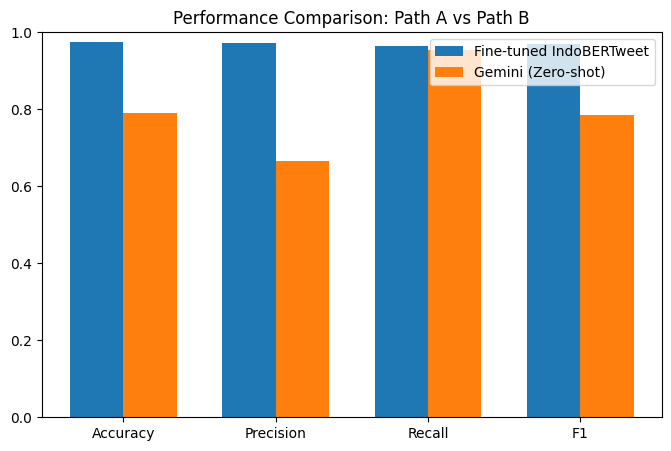

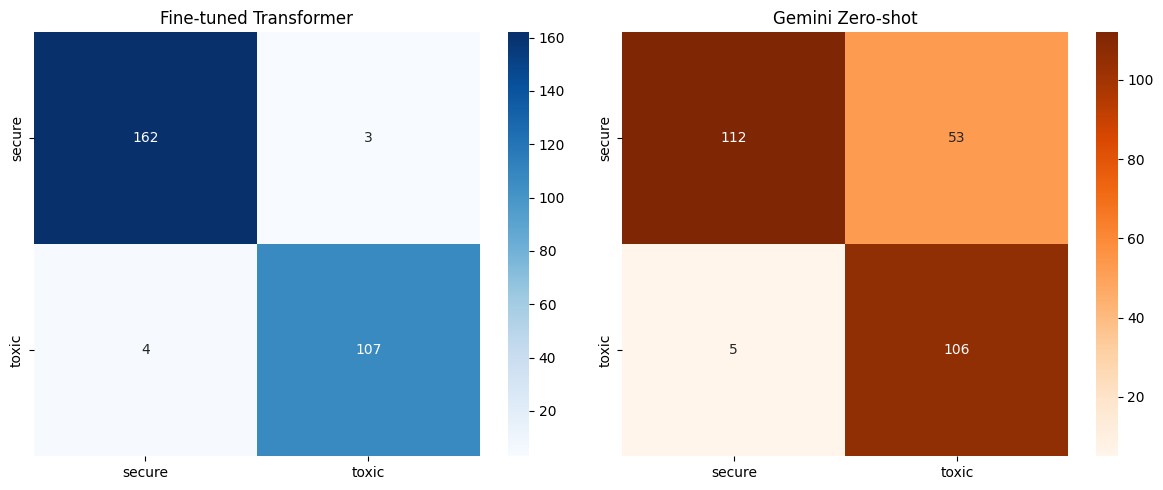

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score, accuracy_score
import numpy as np

# Chart 1: Bar chart perbandingan metrik
metrics_bert = [accuracy_score(y_true_compare, y_pred_bert_compare), precision_score(y_true_compare, y_pred_bert_compare),
                recall_score(y_true_compare, y_pred_bert_compare), f1_score(y_true_compare, y_pred_bert_compare)]
metrics_llm = [accuracy_score(y_true_compare, y_pred_llm_compare), precision_score(y_true_compare, y_pred_llm_compare),
               recall_score(y_true_compare, y_pred_llm_compare), f1_score(y_true_compare, y_pred_llm_compare)]

x = np.arange(4)
width = 0.35
fig, ax = plt.subplots(figsize=(8,5))
ax.bar(x - width/2, metrics_bert, width, label='Fine-tuned IndoBERTweet')
ax.bar(x + width/2, metrics_llm, width, label='Gemini (Zero-shot)')
ax.set_xticks(x); ax.set_xticklabels(['Accuracy','Precision','Recall','F1']); ax.set_ylim(0,1)
ax.legend(); ax.set_title('Performance Comparison: Path A vs Path B')
plt.savefig('perbandingan_jalur.png', dpi=200, bbox_inches='tight')
plt.show()

# Chart 2: Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.heatmap(confusion_matrix(y_true_compare, y_pred_bert_compare), annot=True, fmt='d', cmap='Blues',
            ax=axes[0], xticklabels=['secure','toxic'], yticklabels=['secure','toxic'])
axes[0].set_title('Fine-tuned Transformer')
sns.heatmap(confusion_matrix(y_true_compare, y_pred_llm_compare), annot=True, fmt='d', cmap='Oranges',
            ax=axes[1], xticklabels=['secure','toxic'], yticklabels=['secure','toxic'])
axes[1].set_title('Gemini Zero-shot')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=200, bbox_inches='tight')
plt.show()

In [36]:
# Retrieve the text that matches the valid_idx (which Gemini has successfully evaluated)
text_matching = [X_test_sample.iloc[i] for i in valid_idx]

df_analisis = pd.DataFrame({
    'text': text_matching,
    'original_label': y_true_compare,
    'prediction_bert': y_pred_bert_compare,
    'prediction_llm': y_pred_llm_compare,
})

print("=== Case of BERT misprediction ===")
wrong_bert = df_analisis[df_analisis['original_label'] != df_analisis['prediction_bert']]
print(wrong_bert.to_string())

print("\n=== Case of Gemini misprediction ===")
wrong_llm = df_analisis[df_analisis['original_label'] != df_analisis['prediction_llm']]
print(wrong_llm.to_string())

print("\n=== MOST INTERESTING: BERT is right, Gemini is wrong ===")
interesting = df_analisis[(df_analisis['original_label'] == df_analisis['prediction_bert']) &
                       (df_analisis['original_label'] != df_analisis['prediction_llm'])]
print(interesting.to_string())

=== Case of BERT misprediction ===
                                                                                                                                                                                                                                                                                              text  original_label  prediction_bert  prediction_llm
19                                                                                                                                                                                                     anjir, sangu goreng buatan kamu teh raos banget euy, matak sayang menambah lagi wae, kehed!               0                1               0
44                                                                                                                                                                                                                            astaga anjing tertawa habis lihat rudi joget teh kayak penguin 

In [37]:
# Create a table comparing the predictions
error_df = pd.DataFrame({
    "text": [X_test_sample.iloc[i] for i in valid_idx],
    "actual": y_true_compare,
    "bert_pred": y_pred_bert_compare,
    "gemini_pred": y_pred_llm_compare
})

# Translations of labels to make them easier to read
label_map = {
    0: "secure",
    1: "toxic"
}

error_df["actual_label"] = error_df["actual"].map(label_map)
error_df["bert_label"] = error_df["bert_pred"].map(label_map)
error_df["gemini_label"] = error_df["gemini_pred"].map(label_map)

# 1. IndoBERTweet right, Gemini wrong
bert_right_gemini_wrong = error_df[
    (error_df["actual"] == error_df["bert_pred"]) &
    (error_df["actual"] != error_df["gemini_pred"])
]

print("=== IndoBERTweet right, Gemini wrong ===")
display(
    bert_right_gemini_wrong[
        ["text", "actual_label", "bert_label", "gemini_label"]
    ].head(10)
)

# 2. Gemini right, IndoBERTweet wrong
gemini_right_bert_wrong = error_df[
    (error_df["actual"] == error_df["gemini_pred"]) &
    (error_df["actual"] != error_df["bert_pred"])
]

print("=== Gemini right, IndoBERTweet wrong ===")
display(
    gemini_right_bert_wrong[
        ["text", "actual_label", "bert_label", "gemini_label"]
    ].head(10)
)

# 3. Both wrong
both_wrong = error_df[
    (error_df["actual"] != error_df["bert_pred"]) &
    (error_df["actual"] != error_df["gemini_pred"])
]

print("=== Both are wrong ===")
display(
    both_wrong[
        ["text", "actual_label", "bert_label", "gemini_label"]
    ].head(10)
)

=== IndoBERTweet right, Gemini wrong ===


,text,actual_label,bert_label,gemini_label
1,"lini masa gue kebak keluhan, (kontol, anjing, ...",secure,secure,toxic
6,padahal dulu amien yang menuduh prabowo dalang...,toxic,toxic,secure
10,rt kalau prabowo yang presiden tanpa istri bis...,toxic,toxic,secure
11,eks pemain bhayangkara terus sekarang di persi...,toxic,toxic,secure
23,"lagi diam teringat batur aku disebut ""bisu"" ku...",secure,secure,toxic
24,"aduh kanjut, eta teh kont- nya sudah lah 😂",secure,secure,toxic
30,dari awal gue dipanggil 'ka selir' sama 'ka se...,secure,secure,toxic
35,"kamu mau mengejek fisik gue adalah bebas we, t...",secure,secure,toxic
38,aduh tau wani ah diajak menonton horor bareng ...,secure,secure,toxic
52,lupa ayahnya kan sudah mati bom bunuh diri di ...,secure,secure,toxic


=== Gemini right, IndoBERTweet wrong ===


,text,actual_label,bert_label,gemini_label
19,"anjir, sangu goreng buatan kamu teh raos bange...",secure,toxic,secure
57,"berbicara bisnis terus, gue juga pengalaman 6 ...",toxic,secure,toxic
80,ini adalah budek sih gendut ',toxic,secure,toxic
123,salah sendiri memilih gubernur yang diusung da...,toxic,secure,toxic
125,"apa sih koe koplak, kocak bgt, kok malah play ...",toxic,secure,toxic


=== Both are wrong ===


,text,actual_label,bert_label,gemini_label
44,astaga anjing tertawa habis lihat rudi joget t...,secure,toxic,toxic
140,"muka putih teuing siga setan, sumpah lamun nin...",secure,toxic,toxic


## D. GUARDRAIL

**MAPPING THE LEVELS OF HATE SPEECH FROM THE DATASET**

Using the HS_Weak, HS_Moderate and HS_Strong columns
from the Ibrohim & Budi dataset to assess the level of severity.

 If HS0 → secure.
If HS1 → check from the highest level:
strong → moderate → weak.

The levels in these cells are derived from the DATASET LABELS,
not from IndoBERTweet predictions.

In [38]:
def set_level(row):
    """Determining the hate speech level based on dataset labels."""
    if row['HS'] == 0:
        return 'secure'
    if row.get('HS_Strong', 0) == 1:
        return 'strong'
    if row.get('HS_Moderate', 0) == 1:
        return 'moderate'
    if row.get('HS_Weak', 0) == 1:
        return 'weak'
    return 'weak'  # fallback if HS=1 but the level is empty

df['level'] = df.apply(set_level, axis=1)
print(df['level'].value_counts())


level
secure      112034
weak         85555
moderate      1694
strong         471
Name: count, dtype: int64


**GUARDRAIL ACTION RULES**

 Determines system actions based on the level:

 secure     → comments are displayed as normal
 weak     → comments are displayed and flagged
 moderate → comments are displayed and flagged
 strong   → comments are blocked and escalated

 This function defines the system’s action rules,
 not the model training process.

In [39]:
def guardrail_measures(level: str) -> dict:
    """Level map -> system action"""
    rules = {
        'secure':     {'action': 'tayang_normal', 'display': True,  'escalation': False},
        'weak':     {'action': 'flag_log',      'display': True,  'escalation': False},
        'moderate': {'action': 'flag_log',      'display': True,  'escalation': False},
        'strong':   {'action': 'blokir',        'display': False, 'escalation': True},
    }
    return rules[level]

for lv in ['secure', 'weak', 'moderate', 'strong']:
    print(lv, '->', guardrail_measures(lv))


secure -> {'action': 'tayang_normal', 'display': True, 'escalation': False}
weak -> {'action': 'flag_log', 'display': True, 'escalation': False}
moderate -> {'action': 'flag_log', 'display': True, 'escalation': False}
strong -> {'action': 'blokir', 'display': False, 'escalation': True}


**MODERATOR QUEUE**

 Holds comments requiring human review.

 Only comments with an ‘escalation’ value of ‘True’ are placed
 in the moderator queue.

 Under the current rules, only the ‘STRONG’ level is placed
 in the moderator queue.

In [40]:
moderator_queue = []

def proses_komentar(text, level_prediction):
  """Processing comments and adding 'strong' level items to the moderator queue."""
  action = guardrail_measures(level_prediction)
  if action['escalation']:
        moderator_queue.append({
            'text': text,
            'level': level_prediction,
            'status': 'waiting_review'
        })
  return action

**END-TO-END COMMENT PREDICTION AND GUARDRAIL**

 This function takes a single new comment and performs the following:

 1. pre-processing
 2. tokenisation
 3. IndoBERTweet prediction
 4. calculation of safe/toxic probability
 5. determination of severity level
 6. determination of guardrail action
 7. adding strong comments to the moderator queue

 The output is returned in the form of a dictionary

In [41]:
import torch
import torch.nn.functional as F

def comment_prediction(text):
    """Performing preprocessing, hate speech prediction, level determination, and guardrail actions."""
    # Use the same pre-processing as for the training data
    text_clean = clean_text(text)

    # Tokenization
    inputs = tokenizer(
        text_clean,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    # Move to device model
    device = model.device
    inputs = {k: v.to(device) for k, v in inputs.items()}

    # Prediction
    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)

    # Convert logits to probabilities
    probabilities = F.softmax(outputs.logits, dim=-1)
    p_secure = probabilities[0][0].item()
    p_toxic = probabilities[0][1].item()

    # Specify the label
    if p_toxic < 0.50:
        level = "secure"
    elif p_toxic < 0.75:
        level = "weak"
    elif p_toxic < 0.90:
        level = "moderate"
    else:
        level = "strong"

    # Jalankan aturan guardrail
    action = proses_komentar(text, level)

    return {
        "text": text,
        "text_clean": text_clean,
        "p_secure": p_secure,
        "p_toxic": p_toxic,
        "level": level,
        "action": action
    }

# E. TESTING & DEMO SISTEM

**COMMENT PREDICTION TEST**

An example of a manual test to examine the prediction results
of IndoBERTweet and the guardrail measures.


In [42]:
# Example of testing predictions for new comments
result = comment_prediction("kamu kaya monkey pig ")

print(result)

{'text': 'kamu kaya monkey pig ', 'text_clean': 'kamu kayak monkey pig', 'p_secure': 0.0030337367206811905, 'p_toxic': 0.9969663023948669, 'level': 'strong', 'action': {'action': 'blokir', 'display': False, 'escalation': True}}


**CHECK MODERATOR QUEUE**

Displays all comments currently in
the moderator queue.


In [43]:
# Menampilkan komentar yang saat ini berada di antrean moderator
print(" MODERATOR QUEUE ")

for item in moderator_queue:
    print(item)

 MODERATOR QUEUE 
{'text': 'kamu kaya monkey pig ', 'level': 'strong', 'status': 'waiting_review'}


**RESET MODERATOR QUEUE**

This cell is only used to clear test results
before carrying out a new demonstration.


In [45]:
# Clearing the moderator queue before the next test
moderator_queue = []

print("Moderator queue:", moderator_queue)

Moderator queue: []


**END-TO-END ANALYSIS FUNCTION**

Encapsulates comment predictions into a single function.

This function takes the prediction results and simplifies them
into information that can be easily used by the UI.


In [61]:
def comment_analysis(text):
    """Generate end-to-end comment analysis results."""
    result = comment_prediction(text)

    level = result['level']
    p_toxic = result['p_toxic']
    action = result['action']

    return {
        'text': text,
        'teks_clean': result['text_clean'],
        'level': level,
        'confidence': p_toxic,
        'Behavior': action
    }


**MODERATION OUTPUT FORMAT**

Displays the analysis results in a format that is easier
for humans to read:
- input
- text after pre-processing
- level
- confidence
- action

This function could form the basis for a web UI.


In [62]:
def show_analysis(text):
    result = comment_analysis(text)

    print(" MODERATION RESULT ")
    print(f"Input      : {result['text']}")
    print(f"Clean text : {result['teks_clean']}")
    print(f"Prediksi   : {result['level'].upper()}")
    print(f"Confidence : {result['confidence'] * 100:.2f}%")

    if result['Behavior']['action'] == 'tayang_normal':
        print("Measure    : Normal Broadcasting")
    elif result['Behavior']['action'] == 'flag_log':
        print("Measure    : TAGGED / LOG IN")
    elif result['Behavior']['action'] == 'blokir':
        print("Measure    : BLOCKED + SENT TO THE MODERATOR’S QUEUE")

**EXAMPLE OF SYSTEM TESTING**

Testing the system using a single example sentence to
check whether the pipeline:

input → pre-processing → prediction → level → action
is functioning correctly.


In [63]:
show_analysis("Muka lu kaya monyet b*go")

 MODERATION RESULT 
Input      : Muka lu kaya monyet b*go
Clean text : muka kamu kayak monyet b*go
Prediksi   : STRONG
Confidence : 99.86%
Measure    : BLOCKED + SENT TO THE MODERATOR’S QUEUE


In [64]:
import gradio as gr

CUSTOM_CSS = """
@import url('https://fonts.googleapis.com/css2?family=Plus+Jakarta+Sans:wght@400;600;700;800&display=swap');

body, .gradio-container {
    background: linear-gradient(135deg, #0b1121 0%, #172554 100%) !important;
    font-family: 'Plus Jakarta Sans', sans-serif !important;
    background-attachment: fixed;
}

/* Glassmorphism App Shell */
#app-shell {
    max-width: 1050px;
    margin: 0 auto;
    background: rgba(255, 255, 255, 0.03) !important;
    backdrop-filter: blur(16px);
    -webkit-backdrop-filter: blur(16px);
    border: 1px solid rgba(255, 255, 255, 0.1);
    border-radius: 24px;
    padding: 35px 30px 40px 30px;
    box-shadow: 0 30px 60px rgba(0,0,0,0.4);
}

/* Header Text Animasi Gradien */
#app-header {
    text-align: center;
    margin-bottom: 30px;
}
#app-header h1 {
    background: linear-gradient(to right, #60a5fa, #a855f7, #60a5fa);
    background-size: 200% auto;
    color: transparent !important;
    -webkit-background-clip: text;
    background-clip: text;
    font-weight: 800;
    font-size: 38px;
    margin-bottom: 8px;
    letter-spacing: -0.5px;
    animation: shine 4s linear infinite;
}
@keyframes shine {
    to { background-position: 200% center; }
}
#app-header p {
    color: #94a3b8 !important;
    font-size: 15px;
    font-weight: 400;
    margin: 0;
}

/* Animation Appears for the Card Panel */
@keyframes slideUpFade {
    from { opacity: 0; transform: translateY(20px); }
    to { opacity: 1; transform: translateY(0); }
}

.panel-card {
    background-color: #ffffff !important;
    border-radius: 16px;
    padding: 24px;
    box-shadow: 0 10px 25px rgba(0,0,0,0.15);
    border: 1px solid rgba(255,255,255,0.6);
    animation: slideUpFade 0.6s ease-out forwards;
    transition: transform 0.3s ease, box-shadow 0.3s ease;
}

/* Hover Effect When the Mouse is Over the Panel */
.panel-card:hover {
    transform: translateY(-4px);
    box-shadow: 0 20px 40px rgba(0,0,0,0.2);
}

/* Correct ALL label/title text to ensure it is high-contrast */
.panel-card *,
.panel-card label,
.panel-card span,
.panel-card p,
.panel-card h1,
.panel-card h2,
.panel-card h3,
.panel-card .section-label {
    color: #0f172a !important;
    font-weight: 700 !important;
}

.section-label {
    font-size: 16px !important;
    border-bottom: 2px solid #e2e8f0;
    padding-bottom: 8px;
    margin-bottom: 16px !important;
    color: #1e3a8a !important; /* Biru tua elegan */
}

/* Styling Input & Output Textbox with Focus Effect (Glow) */
textarea, input[type="text"] {
    background-color: #f8fafc !important;
    border: 1px solid #cbd5e1 !important;
    border-radius: 12px !important;
    color: #0f172a !important;
    font-weight: 600 !important;
    transition: all 0.3s ease !important;
}
textarea:focus, input[type="text"]:focus {
    border-color: #3b82f6 !important;
    box-shadow: 0 0 0 4px rgba(59, 130, 246, 0.2) !important;
    background-color: #ffffff !important;
}

/* Button Styling Examples (Example Comments) */
.panel-card button[class*="gallery-item"],
.panel-card [id*="component"] button {
    background-color: #ffffff !important;
    border: 1px solid #cbd5e1 !important;
    color: #3b82f6 !important;
    font-weight: 600 !important;
    border-radius: 8px !important;
    transition: all 0.2s ease;
}
.panel-card button[class*="gallery-item"]:hover {
    background-color: #eff6ff !important;
    border-color: #3b82f6 !important;
    transform: scale(1.02);
}

/* Styling Accordion */
#app-shell [class*="accordion"] {
    background-color: #f8fafc !important;
    border: 1px solid #cbd5e1 !important;
    border-radius: 12px !important;
    margin-top: 12px;
    transition: all 0.3s ease;
}
#app-shell [class*="accordion"]:hover {
    border-color: #94a3b8 !important;
}

/* MAIN BUTTON ANIMATION (Liquid Gradient) */
#analyze_btn {
    background: linear-gradient(45deg, #1d4ed8, #4f46e5, #1d4ed8) !important;
    background-size: 200% auto !important;
    color: #ffffff !important;
    font-weight: 800 !important;
    font-size: 15px !important;
    border-radius: 12px !important;
    border: none !important;
    box-shadow: 0 4px 15px rgba(79, 70, 229, 0.4) !important;
    transition: all 0.3s ease !important;
}
#analyze_btn:hover {
    background-position: right center !important;
    transform: translateY(-3px) scale(1.02) !important;
    box-shadow: 0 8px 25px rgba(79, 70, 229, 0.6) !important;
}
#analyze_btn:active {
    transform: translateY(1px) scale(0.98) !important; /* Efek ditekan */
}
#analyze_btn * {
    color: #ffffff !important;
}

/* Clear Button */
#clear_btn {
    background-color: #f1f5f9 !important;
    color: #475569 !important;
    font-weight: 700 !important;
    border-radius: 12px !important;
    border: 1px solid #cbd5e1 !important;
    transition: all 0.2s ease !important;
}
#clear_btn:hover {
    background-color: #e2e8f0 !important;
    color: #0f172a !important;
    transform: translateY(-2px);
}
#clear_btn * {
    color: inherit !important;
}

/* Moderator View Section */
#moderator-title {
    text-align: center;
    color: #ffffff !important;
    font-weight: 800 !important;
    margin-top: 40px !important;
    margin-bottom: 16px !important;
    font-size: 24px !important;
    text-shadow: 0 2px 10px rgba(0,0,0,0.5);
}

#moderator-card {
    background-color: #ffffff !important;
    border-radius: 16px;
    padding: 24px;
    box-shadow: 0 10px 30px rgba(0,0,0,0.3);
    animation: slideUpFade 0.8s ease-out forwards;
}
#moderator-card * {
    color: #0f172a !important;
}

#refresh_btn {
    background-color: #eff6ff !important;
    color: #1d4ed8 !important;
    font-weight: 800 !important;
    border-radius: 10px !important;
    border: 1px solid #bfdbfe !important;
    transition: all 0.2s ease !important;
}
#refresh_btn:hover {
    background-color: #dbeafe !important;
    transform: scale(1.01);
}

#status_box textarea {
    font-weight: 800 !important;
    color: #1d4ed8 !important;
    font-size: 15px !important;
}
"""

def run_analysis(text):
    """Called when the ‘Comment Analysis’ button is pressed."""
    if not text or not text.strip():
        return (
            "-", "-", "-",
            "⚠️ Please enter a comment first.",
            format_blocked_list(),
        )

    result = comment_analysis(text)  # Functions of a notebook (Section E)

    level_text = result["level"].upper()
    conf_text = f"{result['confidence'] * 100:.2f}%"
    preprocess_text = result["teks_clean"]

    action = result["Behavior"]["action"]
    if action == "tayang_normal":
        status_text = "✅ DISPLAYED NORMALLY"
    elif action == "flag_log":
        status_text = "⚠️ FLAGGED / SENT TO LOG"
    elif action == "blokir":
        status_text = "⛔ BLOCKED + SENT TO MODERATOR QUEUE"
    else:
        status_text = action

    return level_text, conf_text, preprocess_text, status_text, format_blocked_list()


def format_blocked_list():
    """Rewrite the contents of the 'moderator_queue' section to make it more readable."""
    if not moderator_queue:  # global variables from the notebook (Section D)
        return "No blocked comments at the moment."

    lines = []
    for i, item in enumerate(moderator_queue, start=1):
        lines.append(
            f"{i}. \"{item['text']}\"\n"
            f"   Level    : {item['level'].upper()}\n"
            f"   Status   : {item['status']}"
        )
    return "\n\n".join(lines)


def clear_all():
    """Called when the 'Clear' button is pressed."""
    return "", "-", "-", "-", "", format_blocked_list()


COMMENT_EXAMPLE = [
    "woi hitam tidur besok jadi budak",
    "semua orang cina harus dibunuh",
    "presiden tergoblok sepanjang sejarah",
    "jhodya mahasiswa tertolol",
]


with gr.Blocks(css=CUSTOM_CSS, title="HateGuard AI") as demo:
    with gr.Column(elem_id="app-shell"):

        gr.HTML(
            """
            <div id="app-header">
                <h1>HateGuard AI</h1>
                <p>Automated Moderation System Based on IndoBERT &amp; Guardrail Severity Levels</p>
            </div>
            """
        )

        with gr.Row():

            # LEFT-HAND COLUMN: Analysis of Public Comments
            with gr.Column(elem_classes="panel-card"):
                gr.Markdown("**Public Comment Analysis**", elem_classes="section-label")
                input_box = gr.Textbox(
                    placeholder="Type or paste the netizen's comment here.",
                    lines=5,
                    show_label=False,
                    elem_id="comments_box",
                )
                gr.Examples(
                    examples=COMMENT_EXAMPLE,
                    inputs=input_box,
                    label="Example comments (click to use)",
                )
                with gr.Row():
                    clear_btn = gr.Button("Clear", elem_id="clear_btn")
                    analyze_btn = gr.Button("Comment Analysis", elem_id="analyze_btn")

            # RIGHT-HAND COLUMN: System Decision Status
            with gr.Column(elem_classes="panel-card"):
                gr.Markdown("**Level Deteksi**", elem_classes="section-label")
                level_box = gr.Textbox(
                    value="-", interactive=False, show_label=False, elem_id="level_box"
                )

                gr.Markdown("**Confidence Toxic**", elem_classes="section-label")
                conf_box = gr.Textbox(
                    value="-", interactive=False, show_label=False, elem_id="conf_box"
                )

                gr.Markdown("**System Status**", elem_classes="section-label")
                status_box = gr.Textbox(
                    value="", interactive=False, show_label=False, elem_id="status_box"
                )

                with gr.Accordion("See the preprocessing process", open=False):
                    preprocess_box = gr.Textbox(
                        value="-",
                        interactive=False,
                        show_label=False,
                        elem_id="preprocess_box",
                        lines=2,
                    )

        # Moderator View
        gr.Markdown("## Moderator View", elem_id="moderator-title")

        with gr.Column(elem_id="moderator-card"):
            with gr.Accordion("Blocked comment queue (Action Required)", open=False):
                refresh_btn = gr.Button(
                    "🔄 Refresh Queue",
                    elem_id="refresh_btn",
                )
                blocked_box = gr.Textbox(
                    value="No blocked comments at the moment.",
                    interactive=False,
                    show_label=False,
                    lines=6,
                    elem_id="blocked_box",
                )

    analyze_btn.click(
        fn=run_analysis,
        inputs=input_box,
        outputs=[level_box, conf_box, preprocess_box, status_box, blocked_box],
    )

    clear_btn.click(
        fn=clear_all,
        inputs=None,
        outputs=[input_box, level_box, conf_box, preprocess_box, status_box, blocked_box],
    )

    refresh_btn.click(
        fn=format_blocked_list,
        inputs=None,
        outputs=blocked_box,
    )

demo.launch(share=True)

/tmp/ipykernel_10788/3491785375.py:278: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: css. Please pass these parameters to launch() instead.
  with gr.Blocks(css=CUSTOM_CSS, title="HateGuard AI") as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://62c686fc895c8a1d31.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
